# Estrategia de medias móviles

En este notebook empiezo a construir la primera estrategia activa del proyecto QuantLab.

La idea básica es comparar dos medias móviles del precio de SPY:

- una media móvil corta;
- una media móvil larga.

En este primer día del sprint solo calcularé y visualizaré las medias móviles. Todavía no ejecutaré el backtest completo.

El objetivo es entender visualmente cómo se comportan las medias móviles respecto al precio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

print("Imports básicos cargados correctamente")

Imports básicos cargados correctamente


## Imports básicos

En este notebook uso:

- `pandas` para trabajar con tablas, series temporales y datos financieros;
- `numpy` para cálculos numéricos;
- `matplotlib.pyplot` para gráficos;
- `Path` para construir rutas de archivos de forma robusta;
- `sys` para poder importar funciones desde la carpeta `src`.

In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

project_root

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab')

## Raíz del proyecto

Localizo la carpeta principal del proyecto para poder construir rutas relativas de forma estable.

Esto evita depender de desde qué carpeta exacta se esté ejecutando el notebook.

In [3]:
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

src_path

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab/src')

## Importar código propio

La carpeta `src/` contiene funciones reutilizables creadas en sprints anteriores.

Para poder importarlas desde el notebook, añado esa carpeta al path de Python.

In [4]:
from backtester import (
    calculate_strategy_returns,
    calculate_equity_curve,
    run_backtest,
    compare_equity_curves,
)

from metrics import (
    total_return,
    annualized_return,
    annualized_volatility,
    drawdown,
    max_drawdown,
    performance_summary,
)

print("Funciones propias importadas correctamente")

Funciones propias importadas correctamente


## Funciones propias importadas

Importo las funciones creadas en el Sprint 2.

Aunque en el Día 1 todavía no necesito ejecutar el backtest completo, dejo importadas las funciones principales porque este notebook crecerá durante el Sprint 3.

Las funciones de `backtester.py` servirán para ejecutar la estrategia cuando tengamos posiciones.

Las funciones de `metrics.py` servirán para evaluar la estrategia más adelante.

In [5]:
processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Archivo usado:", data_file)

Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


## Archivo de datos

Uso el archivo de datos de SPY descargado en el Sprint 1.

Doy prioridad a la versión procesada si existe. Si no existe, uso la versión guardada en `data/raw`.

In [6]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [7]:
spy.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-26,728.989990,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.000000,741.559998,732.090027,736.530029,58035200
2026-06-30,746.770020,746.770020,748.020020,740.890015,741.289978,55626000
2026-07-01,745.760010,745.760010,749.440002,742.380005,745.000000,47100900
2026-07-02,744.780029,744.780029,751.309998,740.030029,747.400024,57447800


In [8]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8413 entries, 1993-01-29 to 2026-07-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  8413 non-null   float64
 1   Close      8413 non-null   float64
 2   High       8413 non-null   float64
 3   Low        8413 non-null   float64
 4   Open       8413 non-null   float64
 5   Volume     8413 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 460.1 KB


## Lectura de datos

Leo el CSV de SPY usando la primera columna como índice de fechas.

El argumento `parse_dates=True` intenta convertir el índice en fechas, lo cual es importante porque estamos trabajando con una serie temporal.

In [9]:
price = spy["Adj Close"].copy()

price.head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

In [10]:
type(price)

pandas.Series

## Precio ajustado

Trabajo con `Adj Close`, el precio ajustado.

Este precio es más apropiado para calcular rentabilidades históricas porque incorpora ajustes como dividendos y splits.

Guardo la columna como una `pd.Series` llamada `price`.

In [11]:
returns = price.pct_change().dropna()

returns.head()

Date
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

In [12]:
returns.describe()

count    8412.000000
mean        0.000476
std         0.011700
min        -0.109424
25%        -0.004316
50%         0.000683
75%         0.005948
max         0.145198
Name: Adj Close, dtype: float64

## Rendimientos diarios

Calculo los rendimientos diarios simples a partir del precio ajustado.

La fórmula es:

\[
R_t = \frac{P_t}{P_{t-1}} - 1
\]

Estos rendimientos serán la entrada principal del backtester cuando ejecutemos la estrategia.

In [13]:
short_window = 20
long_window = 100

short_window, long_window

(20, 100)

## Ventanas de medias móviles

Voy a usar dos ventanas iniciales:

- media móvil corta: 20 días;
- media móvil larga: 100 días.

La media de 20 días representa una tendencia más rápida.

La media de 100 días representa una tendencia más lenta.

In [14]:
short_ma = price.rolling(window=short_window).mean()
long_ma = price.rolling(window=long_window).mean()

short_ma.head(25)

Date
1993-01-29          NaN
1993-02-01          NaN
1993-02-02          NaN
1993-02-03          NaN
1993-02-04          NaN
1993-02-05          NaN
1993-02-08          NaN
1993-02-09          NaN
1993-02-10          NaN
1993-02-11          NaN
1993-02-12          NaN
1993-02-16          NaN
1993-02-17          NaN
1993-02-18          NaN
1993-02-19          NaN
1993-02-22          NaN
1993-02-23          NaN
1993-02-24          NaN
1993-02-25          NaN
1993-02-26    24.297628
1993-03-01    24.307060
1993-03-02    24.325926
1993-03-03    24.347363
1993-03-04    24.349078
1993-03-05    24.342218
Name: Adj Close, dtype: float64

In [15]:
long_ma.head(105)

Date
1993-01-29          NaN
1993-02-01          NaN
1993-02-02          NaN
1993-02-03          NaN
1993-02-04          NaN
                ...    
1993-06-23    24.609955
1993-06-24    24.615955
1993-06-25    24.621267
1993-06-28    24.626782
1993-06-29    24.630055
Name: Adj Close, Length: 105, dtype: float64

## Medias móviles

Calculo las medias móviles usando `.rolling(window).mean()`.

Una media móvil de 20 días calcula, para cada fecha, la media de los últimos 20 precios disponibles.

Una media móvil de 100 días hace lo mismo, pero usando los últimos 100 precios.

Por eso al principio aparecen valores `NaN`: todavía no hay suficientes datos para llenar la ventana.

In [16]:
ma_data = pd.DataFrame({
    "price": price,
    "short_ma": short_ma,
    "long_ma": long_ma,
})

ma_data.head(110)

,price,short_ma,long_ma
Date,,,
1993-01-29,24.113268,NaN,NaN
1993-02-01,24.284761,NaN,NaN
1993-02-02,24.336224,NaN,NaN
1993-02-03,24.593477,NaN,NaN
1993-02-04,24.696363,NaN,NaN
...,...,...,...
1993-06-30,25.023575,24.852108,24.633498
1993-07-01,24.954165,24.847105,24.636247
1993-07-02,24.815323,24.839466,24.639323


In [17]:
ma_data.isna().sum()

price        0
short_ma    19
long_ma     99
dtype: int64

## Tabla de revisión

Construyo una tabla con el precio y las dos medias móviles.

Esta tabla me permite comprobar cuándo empiezan a aparecer valores válidos en cada media móvil.

La media móvil de 20 días empieza antes que la de 100 días porque necesita menos observaciones.

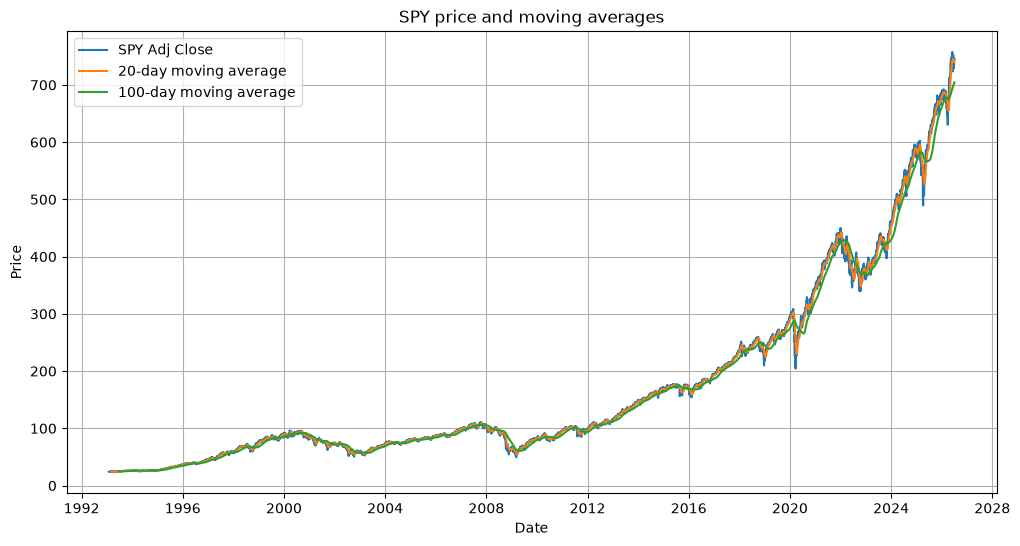

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(ma_data.index, ma_data["price"], label="SPY Adj Close")
plt.plot(ma_data.index, ma_data["short_ma"], label=f"{short_window}-day moving average")
plt.plot(ma_data.index, ma_data["long_ma"], label=f"{long_window}-day moving average")

plt.title("SPY price and moving averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Visualización completa

En este gráfico comparo el precio de SPY con sus medias móviles.

La media móvil corta se mueve más cerca del precio.

La media móvil larga es más suave y reacciona más lentamente.

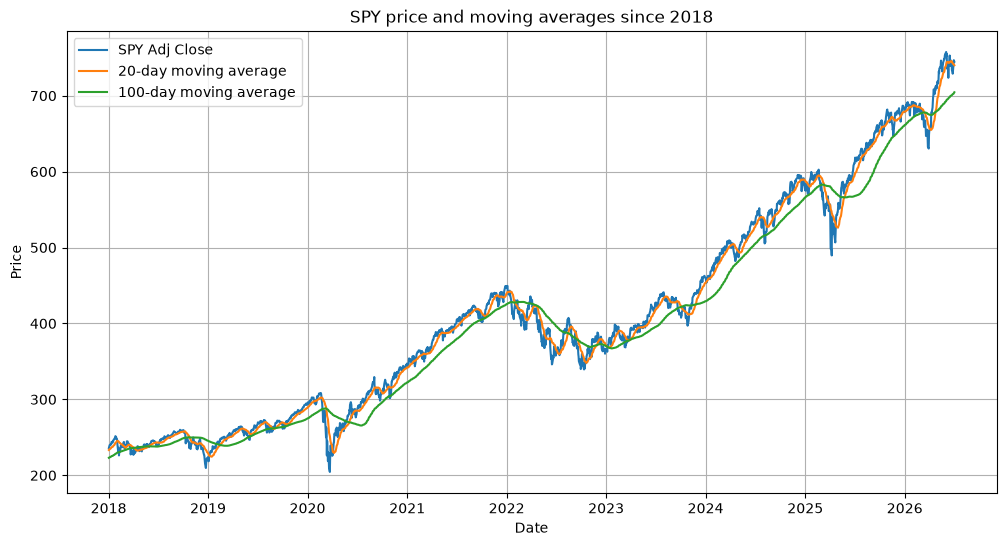

In [19]:
recent_ma_data = ma_data.loc["2018":].copy()

plt.figure(figsize=(12, 6))

plt.plot(recent_ma_data.index, recent_ma_data["price"], label="SPY Adj Close")
plt.plot(recent_ma_data.index, recent_ma_data["short_ma"], label=f"{short_window}-day moving average")
plt.plot(recent_ma_data.index, recent_ma_data["long_ma"], label=f"{long_window}-day moving average")

plt.title("SPY price and moving averages since 2018")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Análisis visual

1. ¿Cuál de las dos medias móviles reacciona más rápido al precio?

La media corta, es más sensible a los cambios porque tiene menos inputs.

2. ¿Cuál de las dos medias móviles es más suave?

La larga, por el mismo motivo

3. ¿Qué parece ocurrir cuando el precio entra en una tendencia bajista fuerte?

La media larga se mantiene más constante y la corta baja con el precio

4. ¿Qué podría significar que la media corta esté por encima de la media larga?

Significa que hay una tendencia creciente

5. ¿Qué podría significar que la media corta esté por debajo de la media larga?

Que hay una tendencia decreciente

In [20]:
def moving_average(series: pd.Series, window: int) -> pd.Series:
    """
    Calculate the moving average of a pandas Series.

    Parameters
    ----------
    series : pd.Series
        Input time series.
    window : int
        Number of observations used to calculate the moving average.

    Returns
    -------
    pd.Series
        Moving average of the input series.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    if not isinstance(window, int):
        raise TypeError("window must be an integer")

    if window <= 0:
        raise ValueError("window must be positive")

    return series.rolling(window=window).mean()

In [21]:
short_ma_function = moving_average(price, short_window)
long_ma_function = moving_average(price, long_window)

short_ma_function.head()

Date
1993-01-29   NaN
1993-02-01   NaN
1993-02-02   NaN
1993-02-03   NaN
1993-02-04   NaN
Name: Adj Close, dtype: float64

In [22]:
(short_ma - short_ma_function).abs().max()

np.float64(0.0)

In [23]:
(long_ma - long_ma_function).abs().max()

np.float64(0.0)

## Tarea extra

He creado una función `moving_average` que encapsula el cálculo de una media móvil.

La función recibe una serie temporal y una ventana, valida los inputs básicos y devuelve la media móvil calculada con `.rolling(window).mean()`.

Esto permite reutilizar el cálculo y evita repetir la misma línea de código varias veces.

In [24]:
sys.path

['C:\\Users\\usuario\\anaconda3\\python311.zip',
 'C:\\Users\\usuario\\anaconda3\\DLLs',
 'C:\\Users\\usuario\\anaconda3\\Lib',
 'C:\\Users\\usuario\\anaconda3',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\.venv',
 '',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\.venv\\Lib\\site-packages',
 'c:\\Users\\usuario\\Documents\\GitHub\\QuantLab\\src']